In [8]:
import tensorflow as tf

In [9]:
tf.__version__

'2.20.0'

In [10]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [11]:
train_dataset = pd.read_csv(r"C:\Users\10hit\OneDrive\Desktop\Course_work\Neural-Computing-and-Deep-Learning-2025-MOD006568-TRI2-F01CAM-\Assignment\part-1\cassava-leaf-disease-classification\train.csv")
train_dataset

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3
...,...,...
21392,999068805.jpg,3
21393,999329392.jpg,3
21394,999474432.jpg,1
21395,999616605.jpg,4


In [12]:
import json

with open(r"C:\Users\10hit\OneDrive\Desktop\Course_work\Neural-Computing-and-Deep-Learning-2025-MOD006568-TRI2-F01CAM-\Assignment\part-1\cassava-leaf-disease-classification\label_num_to_disease_map.json") as f:
    label_map = json.load(f)

print("\n--- Distribution of Classes ---")

class_counts_df = train_dataset['label'].value_counts().sort_index().reset_index()
class_counts_df.columns = ['label', 'count']

print(class_counts_df)


class_counts_df['class_name'] = class_counts_df['label'].astype(str).map(label_map)

print("\nFinal DataFrame:")
print(class_counts_df)
print("\nInfo:")
print(class_counts_df.info())


--- Distribution of Classes ---
   label  count
0      0   1087
1      1   2189
2      2   2386
3      3  13158
4      4   2577

Final DataFrame:
   label  count                           class_name
0      0   1087       Cassava Bacterial Blight (CBB)
1      1   2189  Cassava Brown Streak Disease (CBSD)
2      2   2386           Cassava Green Mottle (CGM)
3      3  13158         Cassava Mosaic Disease (CMD)
4      4   2577                              Healthy

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       5 non-null      int64 
 1   count       5 non-null      int64 
 2   class_name  5 non-null      object
dtypes: int64(2), object(1)
memory usage: 248.0+ bytes
None


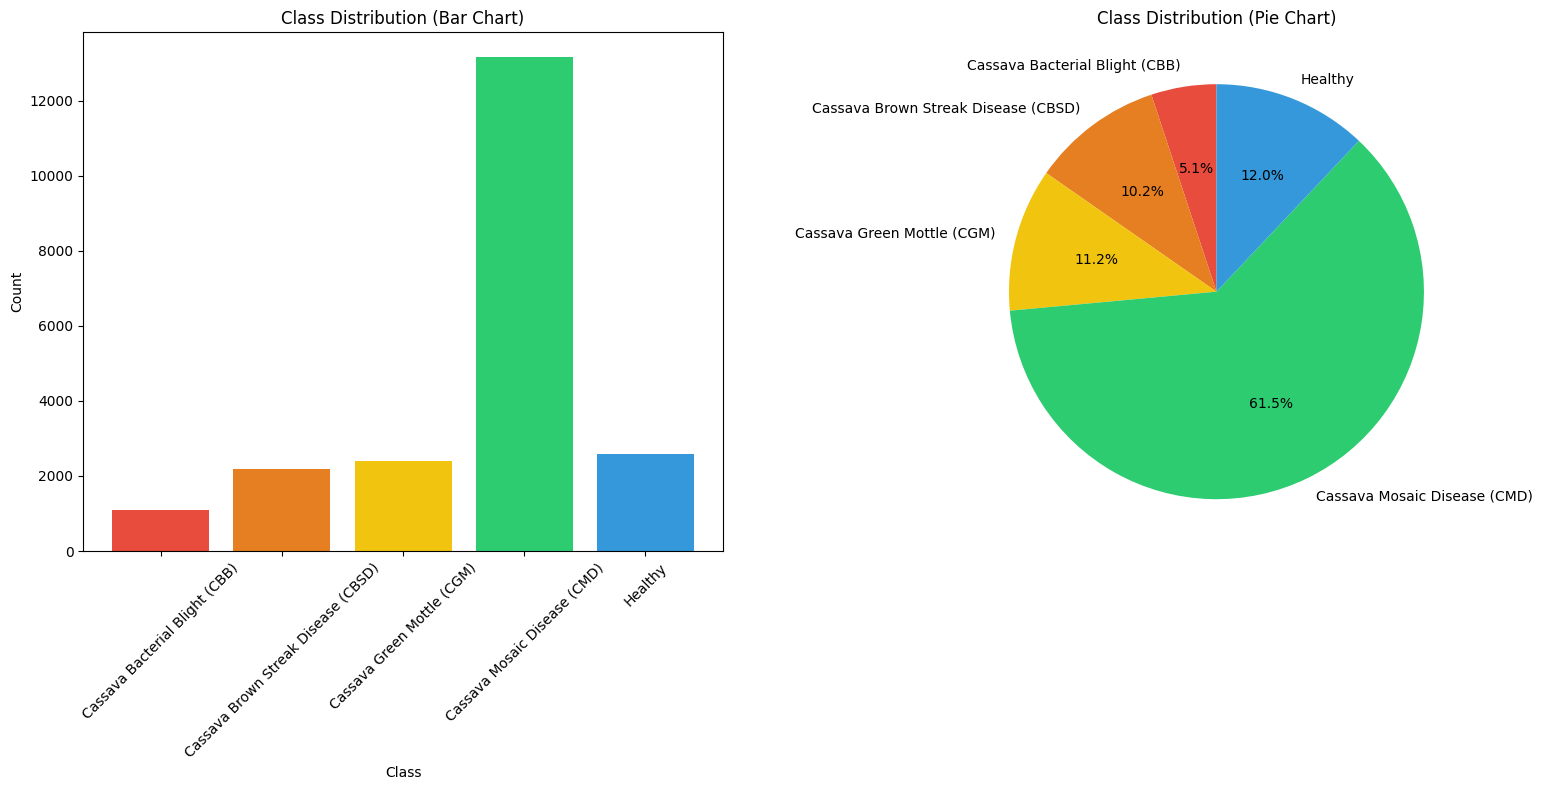

In [13]:
fig, axes = plt.subplots(1,2, figsize=(16,8))

#bar plot
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
axes[0].bar(class_counts_df['class_name'], class_counts_df['count'], color=colors)
axes[0].set_title("Class Distribution (Bar Chart)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

#pie plot

axes[1].pie(
    class_counts_df['count'],
    labels=class_counts_df['class_name'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
axes[1].set_title("Class Distribution (Pie Chart)")

plt.tight_layout()
plt.show()

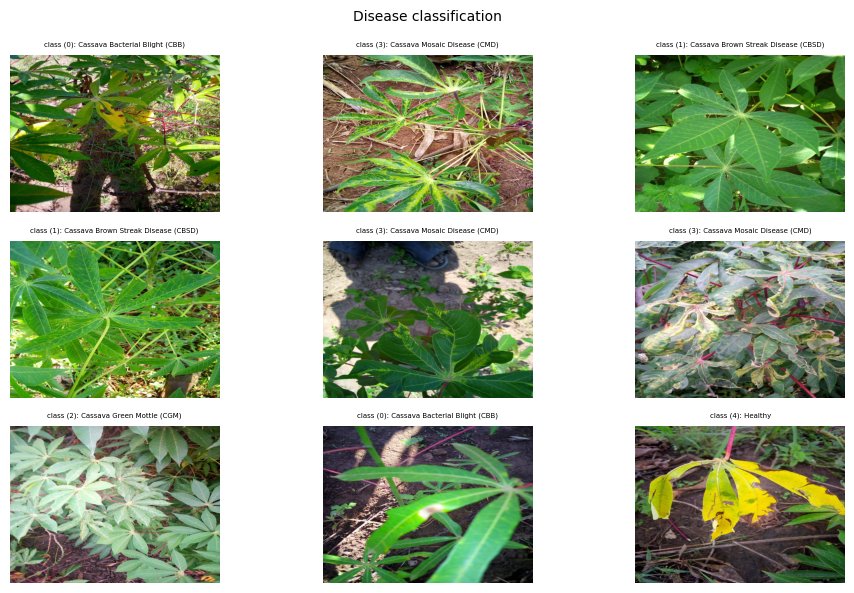

In [14]:
# Lets see the different images with their disease name in it.
from PIL import Image
import os

image_dir = r"C:\Users\10hit\OneDrive\Desktop\Course_work\Neural-Computing-and-Deep-Learning-2025-MOD006568-TRI2-F01CAM-\Assignment\part-1\cassava-leaf-disease-classification\train_images"

fig, axes = plt.subplots(3, 3, figsize=(10,6))

for idx in range(9):  
    row = idx // 3
    col = idx % 3
    
    image_name = train_dataset.iloc[idx, 0]
    label = train_dataset.iloc[idx]['label']
    class_name = label_map[str(label)]
    
    full_dir = os.path.join(image_dir, str(image_name))
    img = Image.open(full_dir)
    
    axes[row, col].imshow(img)
    axes[row, col].set_title(f"class ({label}): {class_name}", fontsize=5)
    axes[row, col].axis('off')

plt.suptitle('Disease classification', fontsize=10)
plt.tight_layout()
plt.show()

## Step 1: Train/Validation Split — Then Balance

**Important order:** split on the *original* data first, then oversample only the training subset. This prevents duplicated images leaking from train into val, which would cause falsely inflated validation accuracy.

- Val set keeps the **real-world class distribution** for an honest evaluation.
- Only the train set is oversampled to **3 000 samples per class**.

In [15]:
from sklearn.model_selection import train_test_split

# 1. Split on raw (unbalanced) data — val reflects real distribution
train_raw_df, val_df = train_test_split(
    train_dataset, test_size=0.2,
    stratify=train_dataset['label'],
    random_state=42
)
print(f'Raw train: {len(train_raw_df)}  |  Val (untouched): {len(val_df)}')
print('Val distribution (real):')
print(val_df['label'].value_counts().sort_index())

# 2. Oversample only the training set
TARGET = 3000
balanced_parts = []
for lbl in sorted(train_raw_df['label'].unique()):
    cls_df = train_raw_df[train_raw_df['label'] == lbl]
    resampled = cls_df.sample(n=TARGET, replace=len(cls_df) < TARGET, random_state=42)
    balanced_parts.append(resampled)

train_df = (
    pd.concat(balanced_parts)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)
print(f'\nBalanced train samples: {len(train_df)}')
print(train_df['label'].value_counts().sort_index())


Raw train: 17117  |  Val (untouched): 4280
Val distribution (real):
label
0     217
1     438
2     477
3    2632
4     516
Name: count, dtype: int64

Balanced train samples: 15000
label
0    3000
1    3000
2    3000
3    3000
4    3000
Name: count, dtype: int64


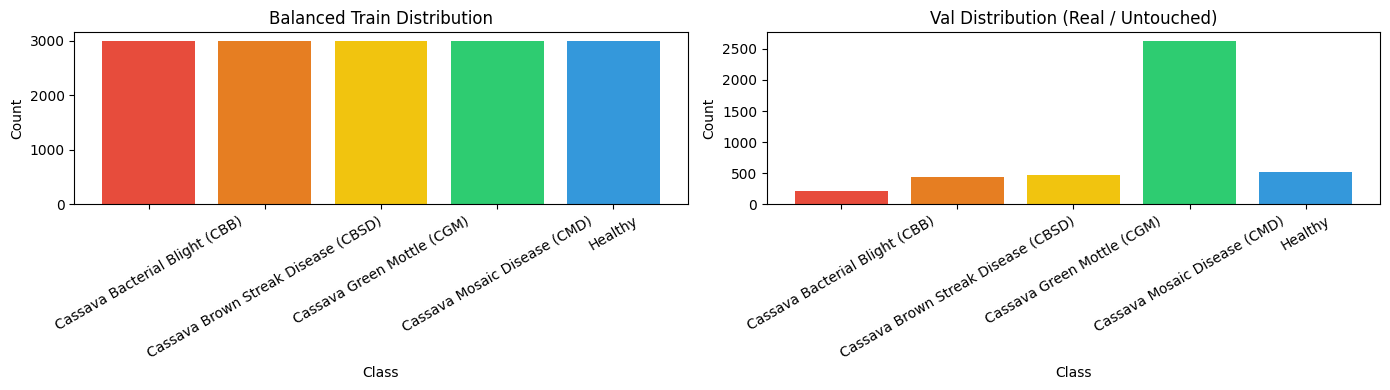

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
class_names = [label_map[str(i)] for i in range(5)]

# Balanced train
axes[0].bar(class_names, train_df['label'].value_counts().sort_index(), color=colors)
axes[0].set_title('Balanced Train Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Real val
axes[1].bar(class_names, val_df['label'].value_counts().sort_index(), color=colors)
axes[1].set_title('Val Distribution (Real / Untouched)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## Step 2: Build the tf.data Pipeline

Images resized to **128 x 128** and normalised to [0, 1]. Training pipeline applies random flip and brightness augmentation.

In [17]:
IMG_SIZE   = 128
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

IMAGE_DIR = r'C:\Users\10hit\OneDrive\Desktop\Course_work\Neural-Computing-and-Deep-Learning-2025-MOD006568-TRI2-F01CAM-\Assignment\part-1\cassava-leaf-disease-classification\train_images'

print(f'Train: {len(train_df)}  |  Val: {len(val_df)}')


Train: 15000  |  Val: 4280


In [18]:
import os

def load_and_preprocess(image_id, label):
    path = tf.strings.join([IMAGE_DIR + os.sep, image_id])
    img  = tf.io.read_file(path)
    img  = tf.image.decode_jpeg(img, channels=3)
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(df, augment_data=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['image_id'].values, df['label'].values.astype('int32'))
    )
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1024)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment_data=True,  shuffle=True)
val_ds   = make_dataset(val_df,   augment_data=False, shuffle=False)
print('Pipeline ready.')


Pipeline ready.


## Step 3: Simple CNN Model

Four convolutional blocks (Conv2D → BatchNorm → MaxPool), then a Dense classifier with Dropout.

In [19]:
from tensorflow.keras import layers, models

def build_simple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=5):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Classifier head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='SimpleCNN')
    return model

model = build_simple_cnn()
model.summary()


c:\Users\10hit\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,782,021 (33.50 MB)

 Trainable params: 8,781,061 (33.50 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 4: Compile and Train

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/25
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.2502 - loss: 4.6355

KeyboardInterrupt: 

## Step 5: Training History

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],    label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],    label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 6: Evaluation — Confusion Matrix & Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_true, y_pred = [], []
for imgs, labels in val_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

val_acc = np.mean(y_true == y_pred)
print(f'Validation Accuracy: {val_acc:.4f}')

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[label_map[str(i)] for i in range(5)])
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, colorbar=False, xticks_rotation=30)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

print('\n--- Classification Report ---')
print(classification_report(
    y_true, y_pred,
    target_names=[label_map[str(i)] for i in range(5)]
))
